<a href="https://colab.research.google.com/github/muhammadfathanfuad/project-machineLearning/blob/main/bismillahfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# 1. IMPORT LIBRARY
# =========================
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# =========================
# 2. MOUNT GOOGLE DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

# =========================
# 3. PATH DATASET
# =========================
DATASET_DIR = Path('/content/drive/MyDrive/dataaaa/DATASET-20260409T061636Z-3-001/DATASET')
TRAIN_DIR = DATASET_DIR / 'Train'
TEST_DIR = DATASET_DIR / 'Test'

assert TRAIN_DIR.exists(), f"Folder train tidak ditemukan: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Folder test tidak ditemukan: {TEST_DIR}"

print("Train dir:", TRAIN_DIR)
print("Test dir :", TEST_DIR)


Mounted at /content/drive
Train dir: /content/drive/MyDrive/dataaaa/DATASET-20260409T061636Z-3-001/DATASET/Train
Test dir : /content/drive/MyDrive/dataaaa/DATASET-20260409T061636Z-3-001/DATASET/Test


In [ ]:
# =========================
# 4. PENGUMPULAN DATASET
# =========================
def collect_image_paths(data_dir):
    data = []
    class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])

    for label in class_names:
        class_dir = data_dir / label
        image_files = list(class_dir.glob('*'))
        image_files = [p for p in image_files if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']]
        for img_path in image_files:
            data.append({
                'filepath': str(img_path),
                'label': label,
                'split_source': data_dir.name
            })

    return pd.DataFrame(data), class_names

train_df_full, class_names = collect_image_paths(TRAIN_DIR)
test_df, _ = collect_image_paths(TEST_DIR)

print("Class names:", class_names)
print("Jumlah data train source:", len(train_df_full))
print("Jumlah data test source :", len(test_df))

Class names: ['angry', 'happy', 'neutral', 'sad']
Jumlah data train source: 10800
Jumlah data test source : 2505



Distribusi train source:
label
happy      3000
neutral    2800
sad        2600
angry      2400
Name: count, dtype: int64

Distribusi test source:
label
happy      1185
neutral     680
sad         478
angry       162
Name: count, dtype: int64


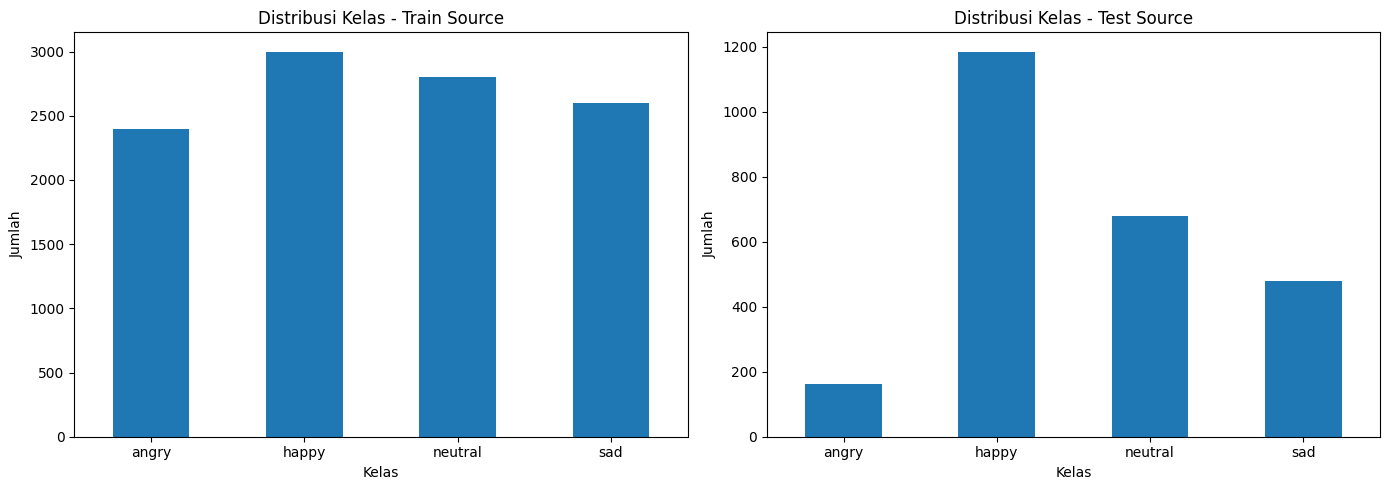

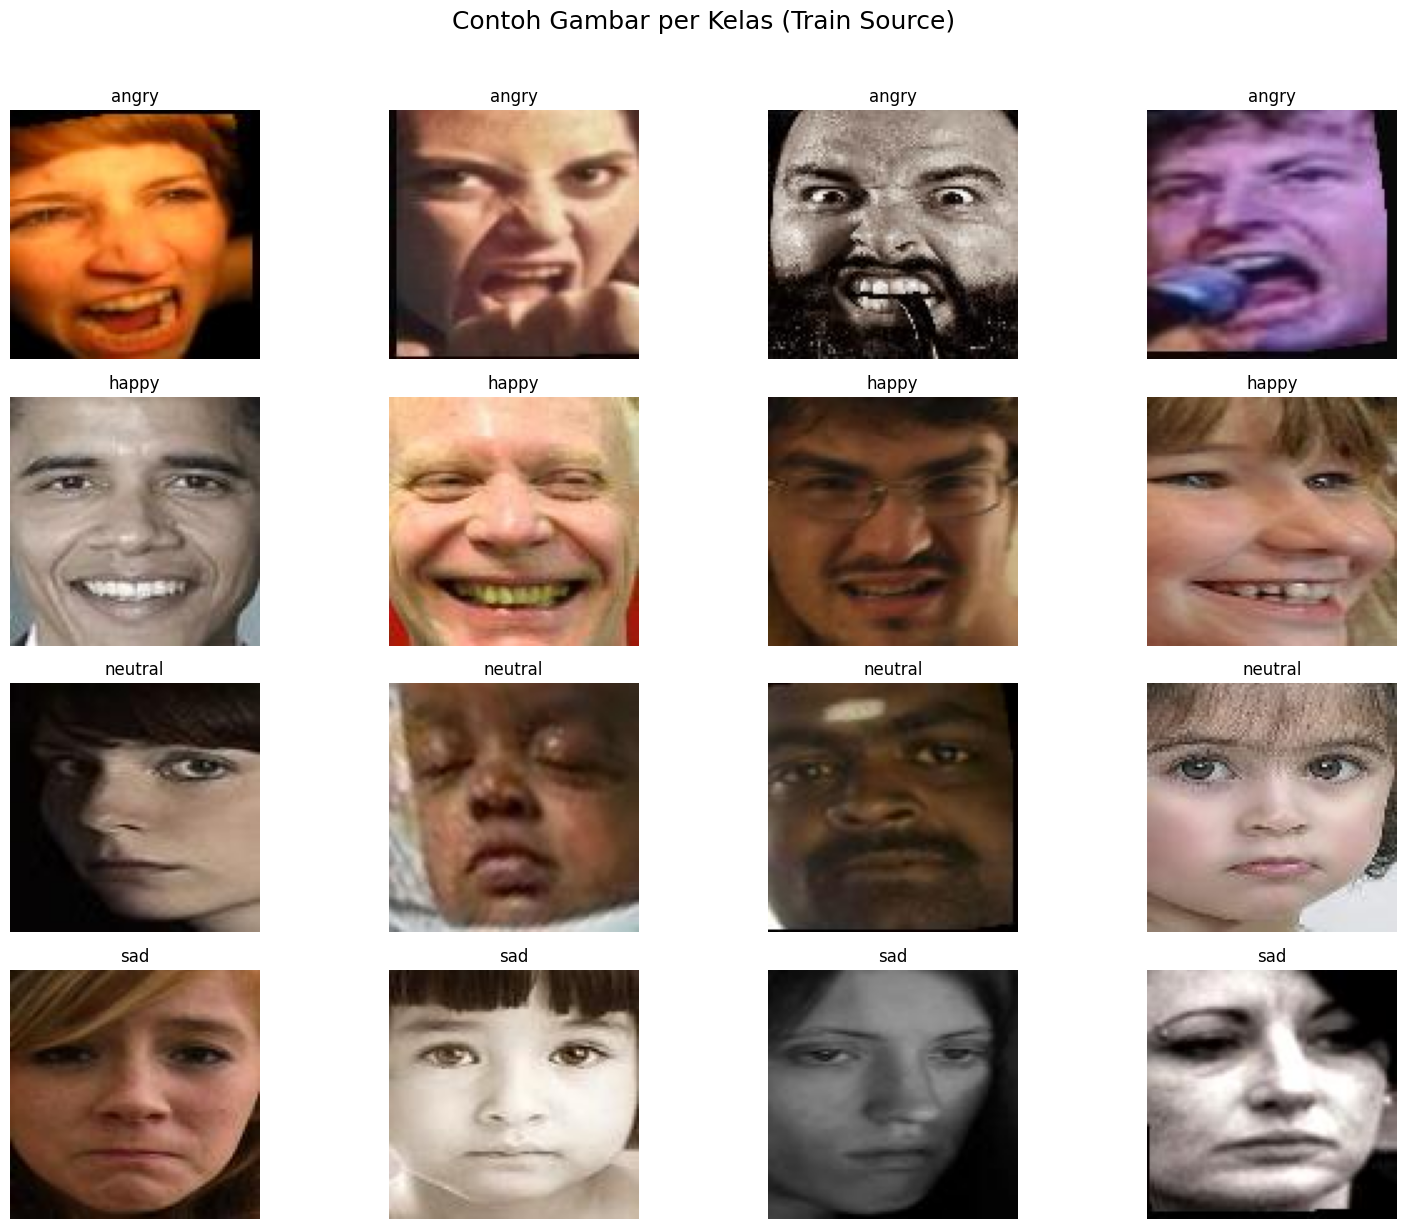

In [ ]:
# =========================
# 5. EKSPLORASI DATASET
# =========================
print("\nDistribusi train source:")
print(train_df_full['label'].value_counts())

print("\nDistribusi test source:")
print(test_df['label'].value_counts())

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
train_df_full['label'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribusi Kelas - Train Source')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
test_df['label'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribusi Kelas - Test Source')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

def show_random_samples(df, title, samples_per_class=4):
    labels = sorted(df['label'].unique())
    rows = len(labels)
    cols = samples_per_class

    plt.figure(figsize=(4 * cols, 3 * rows))
    for r, label in enumerate(labels):
        label_df = df[df['label'] == label]
        label_samples = label_df.sample(min(samples_per_class, len(label_df)), random_state=SEED)

        for c, (_, row) in enumerate(label_samples.iterrows()):
            plt.subplot(rows, cols, r * cols + c + 1)
            img = Image.open(row['filepath']).convert('RGB')
            plt.imshow(img)
            plt.title(label)
            plt.axis('off')

    plt.suptitle(title, fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

show_random_samples(train_df_full, 'Contoh Gambar per Kelas (Train Source)', samples_per_class=4)

In [ ]:
# =========================
# 6. PREPROCESSING & SPLIT
# =========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
INITIAL_EPOCHS = 15
FINE_TUNE_EPOCHS = 8
NUM_CLASSES = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE

train_df, val_df = train_test_split(
    train_df_full,
    test_size=0.2,
    stratify=train_df_full['label'],
    random_state=SEED,
)

print("\nJumlah setelah split:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

class_to_index = {name: idx for idx, name in enumerate(class_names)}
index_to_class = {idx: name for name, idx in class_to_index.items()}

print("\nMapping label:")
print(class_to_index)


Jumlah setelah split:
Train: 8640
Val  : 2160
Test : 2505

Mapping label:
{'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3}


In [ ]:
# =========================
# 7. CLASS WEIGHT
# =========================
y_train_numeric = train_df['label'].map(class_to_index).values
classes = np.unique(y_train_numeric)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_numeric)
class_weight = dict(zip(classes, weights))

print("\nClass weight:")
print(class_weight)



Class weight:
{np.int64(0): np.float64(1.125), np.int64(1): np.float64(0.9), np.int64(2): np.float64(0.9642857142857143), np.int64(3): np.float64(1.0384615384615385)}


In [ ]:
# =========================
# 8. AUGMENTATION
# =========================
train_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.08),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
], name='train_augmentation')

In [ ]:
# =========================
# 9. CLAHE
# =========================
def apply_clahe_numpy(img):
    img = img.astype(np.uint8)
    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_yuv[:, :, 0] = clahe.apply(img_yuv[:, :, 0])
    img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)
    return img.astype(np.float32)

def tf_apply_clahe(image, label):
    image = tf.numpy_function(apply_clahe_numpy, [image], tf.float32)
    image.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
    return image, label


In [ ]:
# =========================
# 10. DATASET PIPELINE
# =========================
def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(df, training=False, apply_clahe=True):
    paths = df['filepath'].values
    labels = df['label'].map(class_to_index).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)

    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)

    if apply_clahe:
        ds = ds.map(tf_apply_clahe, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(lambda x, y: (train_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True, apply_clahe=True)
val_ds = make_dataset(val_df, training=False, apply_clahe=True)
test_ds = make_dataset(test_df, training=False, apply_clahe=True)

In [ ]:
# =========================
# 11. LOSS FUNCTION
# =========================
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()


In [ ]:
# =========================
# 12. MODEL CNN UPGRADE
# =========================
def conv_block(x, filters, dropout_rate=0.25):
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    return x

def build_stronger_cnn(input_shape=(224, 224, 3), num_classes=4):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Rescaling(1./255)(inputs)

    x = conv_block(x, 32, dropout_rate=0.15)
    x = conv_block(x, 64, dropout_rate=0.20)
    x = conv_block(x, 128, dropout_rate=0.25)
    x = conv_block(x, 256, dropout_rate=0.30)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Dropout(0.40)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name='Stronger_CNN')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model

In [ ]:
# =========================
# 13. MODEL MOBILENETV2
# =========================
def build_mobilenetv2_model(input_shape=(224, 224, 3), num_classes=4):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name='MobileNetV2')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model, base_model


In [ ]:
# =========================
# 14. MODEL RESNET50
# =========================
def build_resnet50_model(input_shape=(224, 224, 3), num_classes=4):
    base_model = tf.keras.applications.ResNet50(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.applications.resnet50.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.40)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name='ResNet50')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model, base_model


In [ ]:
# =========================
# 15. CALLBACKS
# =========================
def get_callbacks(model_name):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            mode='max',
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            verbose=1,
            min_lr=1e-6
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'/content/{model_name}_best.keras',
            monitor='val_accuracy',
            mode='max',
            save_best_only=True,
            verbose=1,
        )
    ]


In [ ]:
# =========================
# 16. TRAIN FUNCTION
# =========================
def train_model(model, model_name, train_ds, val_ds, epochs=15, class_weight=None):
    print(f"\nTraining {model_name} ...")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=get_callbacks(model_name),
        class_weight=class_weight,
        verbose=1
    )
    return history


In [ ]:
# =========================
# 17. FINE-TUNING FUNCTION
# =========================
def fine_tune_model(model, base_model, model_name, train_ds, val_ds, unfreeze_last_layers=30, fine_tune_epochs=8):
    print(f"\nFine-tuning {model_name} ...")

    base_model.trainable = True

    if unfreeze_last_layers < len(base_model.layers):
        for layer in base_model.layers[:-unfreeze_last_layers]:
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss=loss_fn,
        metrics=['accuracy']
    )

    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=fine_tune_epochs,
        callbacks=get_callbacks(f"{model_name}_finetune"),
        class_weight=class_weight,
        verbose=1
    )
    return history_ft

In [ ]:
# =========================
# 18. BUILD MODEL
# =========================
cnn_model = build_stronger_cnn(input_shape=IMG_SIZE + (3,), num_classes=NUM_CLASSES)
mobilenet_model, mobilenet_base = build_mobilenetv2_model(input_shape=IMG_SIZE + (3,), num_classes=NUM_CLASSES)
resnet_model, resnet_base = build_resnet50_model(input_shape=IMG_SIZE + (3,), num_classes=NUM_CLASSES)

cnn_model.summary()

In [ ]:
# =========================
# 19. TRAINING STAGE 1
# =========================
history_cnn = train_model(
    cnn_model, 'cnn_upgrade', train_ds, val_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weight
)

history_mobilenet = train_model(
    mobilenet_model, 'mobilenetv2_stage1', train_ds, val_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weight
)

history_resnet = train_model(
    resnet_model, 'resnet50_stage1', train_ds, val_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weight
)

In [ ]:
# =========================
# 20. TRAINING STAGE 2 - FINE TUNING
# =========================
history_mobilenet_ft = fine_tune_model(
    mobilenet_model,
    mobilenet_base,
    'mobilenetv2',
    train_ds,
    val_ds,
    unfreeze_last_layers=30,
    fine_tune_epochs=FINE_TUNE_EPOCHS
)

history_resnet_ft = fine_tune_model(
    resnet_model,
    resnet_base,
    'resnet50',
    train_ds,
    val_ds,
    unfreeze_last_layers=40,
    fine_tune_epochs=FINE_TUNE_EPOCHS
)


In [ ]:
# =========================
# 21. EVALUASI
# =========================
def get_true_labels(df):
    return df['label'].map(class_to_index).values

def predict_labels(model, dataset):
    probs = model.predict(dataset, verbose=0)
    preds = np.argmax(probs, axis=1)
    return preds, probs

def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm)
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel='Predicted Label',
        ylabel='True Label',
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black'
            )
    fig.tight_layout()
    plt.show()

def evaluate_model(model, model_name, dataset, y_true, class_names):
    y_pred, y_prob = predict_labels(model, dataset)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)

    print(f"\n===== {model_name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(report)

    plot_confusion_matrix(cm, class_names, title=f'Confusion Matrix - {model_name}')

    return {
        'model': model_name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'confusion_matrix': cm,
        'classification_report': report,
    }

y_test = get_true_labels(test_df)

results_cnn = evaluate_model(cnn_model, 'CNN Upgrade', test_ds, y_test, class_names)
results_mobilenet = evaluate_model(mobilenet_model, 'MobileNetV2 Fine-tuned', test_ds, y_test, class_names)
results_resnet = evaluate_model(resnet_model, 'ResNet50 Fine-tuned', test_ds, y_test, class_names)


In [ ]:
# =========================
# 22. VISUALISASI HISTORY
# =========================
def plot_training_history(history, title):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 5))
    plt.plot(hist['accuracy'], label='Train Accuracy')
    plt.plot(hist['val_accuracy'], label='Val Accuracy')
    plt.title(f'Accuracy - {title}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(hist['loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.title(f'Loss - {title}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_training_history(history_cnn, 'CNN Upgrade')
plot_training_history(history_mobilenet, 'MobileNetV2 Stage 1')
plot_training_history(history_mobilenet_ft, 'MobileNetV2 Fine-tuning')
plot_training_history(history_resnet, 'ResNet50 Stage 1')
plot_training_history(history_resnet_ft, 'ResNet50 Fine-tuning')

In [ ]:
# =========================
# 23. SAMPLE PREDICTION
# =========================
def show_predictions(model, df, class_names, num_samples=12):
    sample_df = df.sample(min(num_samples, len(df)), random_state=SEED).reset_index(drop=True)
    cols = 4
    rows = int(np.ceil(len(sample_df) / cols))

    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, row in sample_df.iterrows():
        img = tf.keras.utils.load_img(row['filepath'], target_size=IMG_SIZE)
        img_arr = tf.keras.utils.img_to_array(img)
        img_arr = apply_clahe_numpy(img_arr)
        pred = model.predict(np.expand_dims(img_arr, axis=0), verbose=0)
        pred_idx = np.argmax(pred)
        pred_label = class_names[pred_idx]
        confidence = np.max(pred)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"True: {row['label']}\nPred: {pred_label} ({confidence:.2f})")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(cnn_model, test_df, class_names)
show_predictions(mobilenet_model, test_df, class_names)
show_predictions(resnet_model, test_df, class_names)

In [ ]:
# =========================
# 24. PERBANDINGAN PERFORMA
# =========================
comparison_df = pd.DataFrame([
    {
        'Model': results_cnn['model'],
        'Accuracy': results_cnn['accuracy'],
        'Precision': results_cnn['precision'],
        'Recall': results_cnn['recall'],
        'F1-score': results_cnn['f1_score'],
    },
    {
        'Model': results_mobilenet['model'],
        'Accuracy': results_mobilenet['accuracy'],
        'Precision': results_mobilenet['precision'],
        'Recall': results_mobilenet['recall'],
        'F1-score': results_mobilenet['f1_score'],
    },
    {
        'Model': results_resnet['model'],
        'Accuracy': results_resnet['accuracy'],
        'Precision': results_resnet['precision'],
        'Recall': results_resnet['recall'],
        'F1-score': results_resnet['f1_score'],
    },
])

comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("\nTabel Perbandingan Model:")
print(comparison_df)

plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Model'], comparison_df['Accuracy'])
plt.title('Perbandingan Accuracy Model')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Model'], comparison_df['F1-score'])
plt.title('Perbandingan F1-score Model')
plt.xlabel('Model')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.show()
